Loaded 20073 ChEMBL records.
ChEMBL records with valid pIC50: 20073
Canonicalizing SMILES (this may take 1-2 minutes)...
Dropped 0 unparseable SMILES. 20073 remain.
CURATION SUMMARY
Final unique compounds: 16159
Blockers (label=1): 9000
Non-blockers (label=0): 7159
Saved to: /content/drive/MyDrive/herg_hackathon/herg_clean.csv
  compound_id                                             smiles     pIC50  \
0  CMPD_00001  Brc1cc(Br)cc([C@H]2C[C@@H](CN3CCCC3)N2Cc2ccccc...  4.602060   
1  CMPD_00002                     Brc1ccc(-c2nc3ccc(Br)cn3n2)cc1  5.000000   
2  CMPD_00003     Brc1ccc(Nc2ccc(CN3CCC4(CC3)OCCc3sccc34)cc2)cc1  5.370323   
3  CMPD_00004                Brc1ccc2[nH]c3c(c2c1)CCCC3Nc1ccccc1  4.522879   
4  CMPD_00005        Brc1ccc2c(NC3=NC[C@@]4(CN5CCC4CC5)O3)ncnn12  5.602060   

   label  n_records sources  
0      0          1  ChEMBL  
1      1          1  ChEMBL  
2      1          2  ChEMBL  
3      0          1  ChEMBL  
4      1          1  ChEMBL  


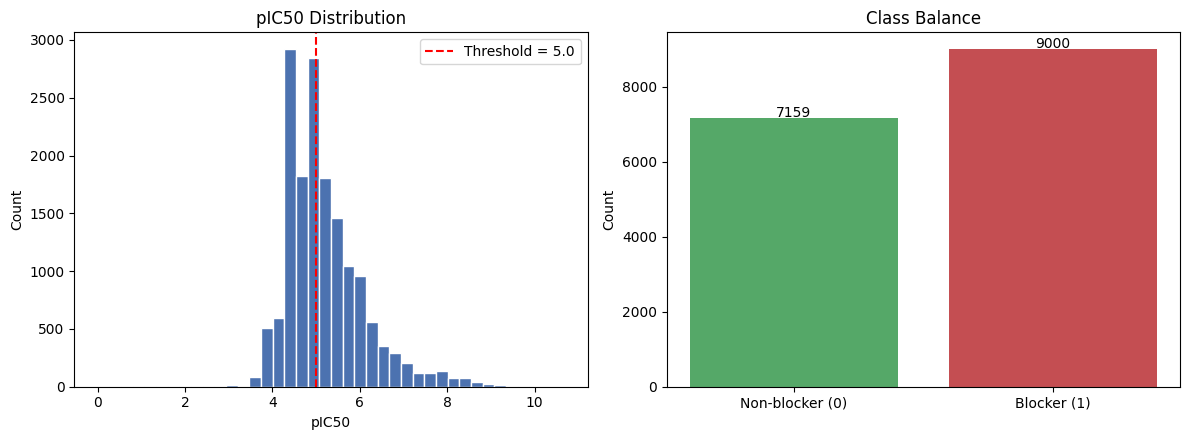

Curation report saved.
# hERG Dataset Curation Report

## Sources
- ChEMBL (target CHEMBL240): 20073 raw bioactivity records with valid pIC50
- TDC hERG: attempted, unavailable (Harvard Dataverse under maintenance at time of pull)

## Curation Steps
1. Canonicalized all SMILES using RDKit (salt stripping, largest-fragment selection)
2. Dropped 0 unparseable SMILES
3. Converted ChEMBL IC50 (nM) to pIC50 = 9 - log10(IC50_nM)
4. Derived binary blocker label: pIC50 >= 5.0 (IC50 <= 10 uM) = blocker
5. De-duplicated on canonical SMILES; conflicting values resolved via median (pIC50) / majority vote (label)

## Final Dataset
- Unique compounds: 16159
- Blockers (label=1): 9000
- Non-blockers (label=0): 7159

## Schema
compound_id, smiles, pIC50, label, n_records, sources



In [5]:
#!pip install -q --force-reinstall --no-deps rdkit

# --- Setup ---
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem.SaltRemover import SaltRemover
import matplotlib.pyplot as plt

SAVE_DIR = '/content/drive/MyDrive/herg_hackathon'
BLOCKER_THRESHOLD_PIC50 = 5.0

remover = SaltRemover()

def canonicalize(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        mol = remover.StripMol(mol, dontRemoveEverything=True)
        frags = Chem.GetMolFrags(mol, asMols=True)
        if len(frags) > 1:
            mol = max(frags, key=lambda m: m.GetNumAtoms())
        return Chem.MolToSmiles(mol, canonical=True)
    except Exception:
        return None

def ic50_to_pic50(value_nm):
    try:
        value_nm = float(value_nm)
        if value_nm <= 0:
            return None
        return 9 - np.log10(value_nm)
    except Exception:
        return None

chembl_df = pd.read_csv(f"{SAVE_DIR}/raw_chembl_herg.csv")
print(f"Loaded {len(chembl_df)} ChEMBL records.")

chembl_df["pIC50"] = chembl_df["standard_value"].apply(ic50_to_pic50)
chembl_df = chembl_df.dropna(subset=["pIC50", "smiles"])
df = chembl_df[["smiles", "pIC50", "source"]].copy()
n_before = len(df)
print(f"ChEMBL records with valid pIC50: {n_before}")

print("Canonicalizing SMILES (this may take 1-2 minutes)...")
df["canonical_smiles"] = df["smiles"].apply(canonicalize)
n_valid = df["canonical_smiles"].notna().sum()
df = df.dropna(subset=["canonical_smiles"])
print(f"Dropped {n_before - n_valid} unparseable SMILES. {len(df)} remain.")

df["label"] = (df["pIC50"] >= BLOCKER_THRESHOLD_PIC50).astype(int)

agg = df.groupby("canonical_smiles").agg(
    pIC50=("pIC50", "median"),
    label=("label", lambda x: int(round(x.astype(float).mean()))),
    n_records=("canonical_smiles", "count"),
    sources=("source", lambda x: ";".join(sorted(set(x)))),
).reset_index()

agg = agg.rename(columns={"canonical_smiles": "smiles"})
agg.insert(0, "compound_id", ["CMPD_" + str(i).zfill(5) for i in range(1, len(agg) + 1)])

out_path = f"{SAVE_DIR}/herg_clean.csv"
agg.to_csv(out_path, index=False)

print("=" * 50)
print("CURATION SUMMARY")
print("=" * 50)
print(f"Final unique compounds: {len(agg)}")
print(f"Blockers (label=1): {(agg['label']==1).sum()}")
print(f"Non-blockers (label=0): {(agg['label']==0).sum()}")
print(f"Saved to: {out_path}")
print(agg.head())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(agg["pIC50"], bins=40, color="#4C72B0", edgecolor="white")
axes[0].axvline(BLOCKER_THRESHOLD_PIC50, color="red", linestyle="--", label=f"Threshold = {BLOCKER_THRESHOLD_PIC50}")
axes[0].set_xlabel("pIC50"); axes[0].set_ylabel("Count"); axes[0].set_title("pIC50 Distribution"); axes[0].legend()

label_counts = agg["label"].value_counts().sort_index()
axes[1].bar(["Non-blocker (0)", "Blocker (1)"], label_counts.values, color=["#55A868", "#C44E52"])
axes[1].set_ylabel("Count"); axes[1].set_title("Class Balance")
for i, v in enumerate(label_counts.values):
    axes[1].text(i, v + 20, str(v), ha="center")

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/data_summary_plots.png", dpi=150)
plt.show()

report = f"""# hERG Dataset Curation Report

## Sources
- ChEMBL (target CHEMBL240): {n_before} raw bioactivity records with valid pIC50
- TDC hERG: attempted, unavailable (Harvard Dataverse under maintenance at time of pull)

## Curation Steps
1. Canonicalized all SMILES using RDKit (salt stripping, largest-fragment selection)
2. Dropped {n_before - n_valid} unparseable SMILES
3. Converted ChEMBL IC50 (nM) to pIC50 = 9 - log10(IC50_nM)
4. Derived binary blocker label: pIC50 >= {BLOCKER_THRESHOLD_PIC50} (IC50 <= 10 uM) = blocker
5. De-duplicated on canonical SMILES; conflicting values resolved via median (pIC50) / majority vote (label)

## Final Dataset
- Unique compounds: {len(agg)}
- Blockers (label=1): {(agg['label']==1).sum()}
- Non-blockers (label=0): {(agg['label']==0).sum()}

## Schema
compound_id, smiles, pIC50, label, n_records, sources
"""

with open(f"{SAVE_DIR}/data_curation_report.md", "w") as f:
    f.write(report)

print("Curation report saved.")
print(report)